In [1]:
import sys
from pathlib import Path
import tensorflow as tf
import numpy as np
import pandas as pd

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)

PROJECT_DIR = Path.cwd().parent

print("Project directory:", PROJECT_DIR)
print("Project exists:", PROJECT_DIR.exists())

Python: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Scripts\python.exe
TensorFlow: 2.21.0
Project directory: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI
Project exists: True


In [2]:
# Load UTKFace metadata

METADATA_DIR = PROJECT_DIR / "outputs" / "metadata"
UTK_METADATA_PATH = METADATA_DIR / "utkface_metadata.csv"

utk_df = pd.read_csv(UTK_METADATA_PATH)

print("UTKFace metadata loaded")
print("-------------------------")
print("Rows:", len(utk_df))
print("Columns:", utk_df.columns.tolist())

print("\nAge statistics:")
print(utk_df["age"].describe())

print("\nGender distribution:")
print(utk_df["gender"].value_counts().sort_index())

print("\nRace distribution:")
print(utk_df["race"].value_counts().sort_index())

UTKFace metadata loaded
-------------------------
Rows: 23705
Columns: ['image_path', 'age', 'gender', 'race']

Age statistics:
count    23705.000000
mean        33.300907
std         19.885708
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64

Gender distribution:
gender
0    12391
1    11314
Name: count, dtype: int64

Race distribution:
race
0    10078
1     4526
2     3434
3     3975
4     1692
Name: count, dtype: int64


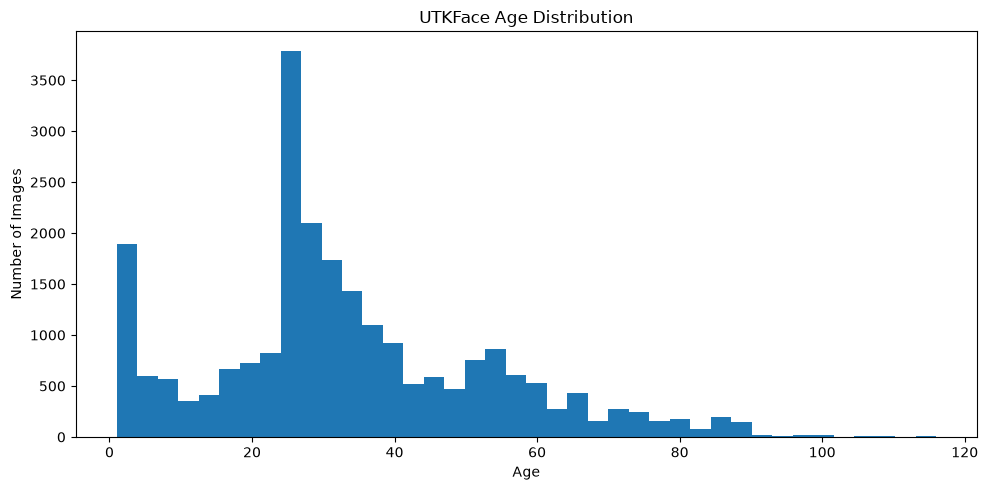

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    utk_df["age"],
    bins=40
)

plt.title("UTKFace Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# Split UTKFace into training and validation sets
age_train_df, age_val_df = train_test_split(
    utk_df,
    test_size=0.20,
    random_state=42
)

age_train_df = age_train_df.reset_index(drop=True)
age_val_df = age_val_df.reset_index(drop=True)

print("Age dataset split completed")
print("----------------------------")
print("Total images     :", len(utk_df))
print("Training images  :", len(age_train_df))
print("Validation images:", len(age_val_df))

print("\nTraining age range:")
print(age_train_df["age"].min(), "to", age_train_df["age"].max())

print("\nValidation age range:")
print(age_val_df["age"].min(), "to", age_val_df["age"].max())

Age dataset split completed
----------------------------
Total images     : 23705
Training images  : 18964
Validation images: 4741

Training age range:
1 to 116

Validation age range:
1 to 111


In [5]:
# Create TensorFlow datasets for age prediction

IMG_SIZE = (128, 128)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def load_age_image(image_path, age):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    
    age = tf.cast(age, tf.float32)
    
    return image, age


# Convert pandas data to TensorFlow datasets
train_paths = age_train_df["image_path"].values
train_ages = age_train_df["age"].values.astype(np.float32)

val_paths = age_val_df["image_path"].values
val_ages = age_val_df["age"].values.astype(np.float32)


train_age_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_ages)
)

val_age_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_ages)
)


# Shuffle training data
train_age_ds = train_age_ds.shuffle(
    buffer_size=len(age_train_df),
    seed=42,
    reshuffle_each_iteration=True
)


# Load images
train_age_ds = train_age_ds.map(
    load_age_image,
    num_parallel_calls=AUTOTUNE
)

val_age_ds = val_age_ds.map(
    load_age_image,
    num_parallel_calls=AUTOTUNE
)


# Batch and prefetch
train_age_ds = train_age_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_age_ds = val_age_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


print("Age TensorFlow datasets created successfully.")
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Training images  :", len(age_train_df))
print("Validation images:", len(age_val_df))

Age TensorFlow datasets created successfully.
Image size : (128, 128)
Batch size : 64
Training images  : 18964
Validation images: 4741


In [6]:
# Inspect one batch from the age dataset

for images, ages in train_age_ds.take(1):
    print("Images shape :", images.shape)
    print("Images dtype :", images.dtype)
    print("Pixel range  :", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))
    print("Ages shape   :", ages.shape)
    print("Ages dtype   :", ages.dtype)
    print("Sample ages  :", ages.numpy()[:20])
    break

Images shape : (64, 128, 128, 3)
Images dtype : <dtype: 'float32'>
Pixel range  : 0.0 to 1.0
Ages shape   : (64,)
Ages dtype   : <dtype: 'float32'>
Sample ages  : [26. 20.  1. 26. 90. 25. 21. 54. 32.  1. 37. 26. 41. 26. 24. 74. 23. 45.
 18. 49.]


In [7]:
from tensorflow.keras import layers, models

age_model = models.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.40),

    layers.Dense(1, activation="linear")
])

age_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,153 (17.49 MB)

 Trainable params: 4,584,193 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
# Compile the age regression model

age_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="mean_absolute_error",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

print("Age model compiled successfully.")
print("Optimizer     : Adam")
print("Learning rate : 0.0001")
print("Loss          : Mean Absolute Error (MAE)")
print("Metrics       : MAE, RMSE")


Age model compiled successfully.
Optimizer     : Adam
Learning rate : 0.0001
Loss          : Mean Absolute Error (MAE)
Metrics       : MAE, RMSE


In [9]:
# Create callbacks for age model training

AGE_MODEL_PATH = PROJECT_DIR / "models" / "age_model_best.keras"

age_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=AGE_MODEL_PATH,
        monitor="val_mae",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_mae",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Age model callbacks created.")
print("Best model path:", AGE_MODEL_PATH)

Age model callbacks created.
Best model path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\age_model_best.keras


In [10]:
# Train the age regression model

EPOCHS = 25

age_history = age_model.fit(
    train_age_ds,
    validation_data=val_age_ds,
    epochs=EPOCHS,
    callbacks=age_callbacks
)

Epoch 1/25


c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 12.8255 - mae: 12.8255 - rmse: 17.3723
Epoch 1: val_mae improved from None to 12.97245, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\age_model_best.keras

Epoch 1: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\age_model_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 699s 2s/step - loss: 12.8255 - mae: 12.8255 - rmse: 17.3723 - val_loss: 12.9724 - val_mae: 12.9724 - val_rmse: 17.3166 - learning_rate: 1.0000e-04
Epoch 2/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 10.2618 - mae: 10.2618 - rmse: 13.8622
Epoch 2: val_mae improved from 12.97245 to 10.24410, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\age_model_best.keras

Epoch 2: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\age_model_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 639s 2s/step - loss: 10.2618 - mae: 10.2618 - rmse: 13.862

In [11]:
# Evaluate the best age model

AGE_MODEL_PATH = PROJECT_DIR / "models" / "age_model_best.keras"

best_age_model = tf.keras.models.load_model(AGE_MODEL_PATH)

print("Best age model loaded successfully.")
print("Model path:", AGE_MODEL_PATH)

age_results = best_age_model.evaluate(
    val_age_ds,
    verbose=1,
    return_dict=True
)

print("\nAge Model Evaluation:")
for metric_name, value in age_results.items():
    print(f"{metric_name}: {value:.4f}")

Best age model loaded successfully.
Model path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\age_model_best.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 276ms/step - loss: 8.7833 - mae: 8.7833 - rmse: 11.7471

Age Model Evaluation:
loss: 8.7833
mae: 8.7833
rmse: 11.7471


In [ ]:
from pathlib import Path
import tensorflow as tf

AGE_MODEL_PATH = PROJECT_DIR / "models" / "age_model_best.keras"

print("Age model exists:", AGE_MODEL_PATH.exists())
print("Age model path:", AGE_MODEL_PATH)

age_check_model = tf.keras.models.load_model(AGE_MODEL_PATH)

print("\nAge model loaded successfully.")
print("Input shape :", age_check_model.input_shape)
print("Output shape:", age_check_model.output_shape)